In [1]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, ttest_ind, shapiro, normaltest

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Gender-Based Analysis of Exam Performance - IN1020 2023

This notebook provides a comprehensive analysis of exam performance differences between male and female students in the IN1020 course for 2023. The analysis includes:

1. **Data Overview and Preparation**
2. **Descriptive Statistics by Gender**
3. **Distribution Analysis and Normality Testing**
4. **Statistical Comparison Between Groups**
5. **Time Analysis and Efficiency**
6. **Effect Size and Practical Significance**
7. **Summary and Conclusions**

## Research Questions:
- Are there significant performance differences between male and female students?
- How do time completion patterns differ by gender?
- What is the magnitude of any observed differences?
- Are the differences practically significant for educational outcomes?

## 1. Data Loading and Initial Overview

In [3]:
df = load_data("../data/cleaned_data/IN1020_2023_cleaned_data.csv")

Data loaded successfully from ../data/cleaned_data/IN1020_2023_cleaned_data.csv


## 2. Data Preparation

We'll prepare separate datasets for different analyses:
- **df_combined**: One record per student with gender and total score
- **df_time**: data including exam timing information
- **df_male**: Data about total score among male students
- **df_male**: Data about total score among female students

Total students: 590
Male students: 327 (55.4%)
Female students: 263 (44.6%)


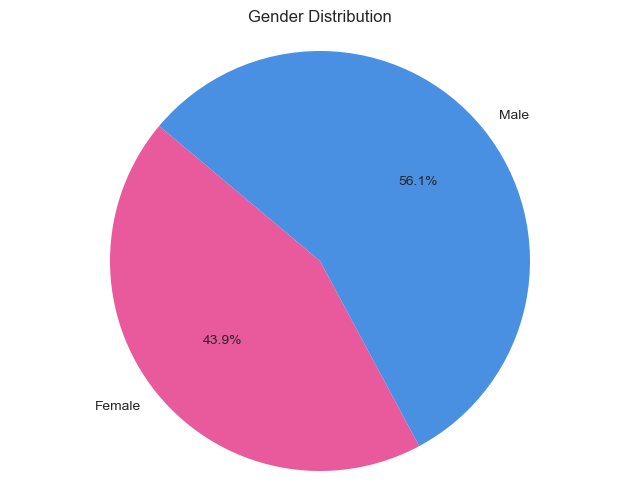

In [4]:
# Prepare student-level dataset with unique records per student
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

# Create gender-specific subsets for analysis
df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

print(f"Total students: {len(df_combined)}")
print(f"Male students: {len(df_male)} ({len(df_male)/len(df_combined)*100:.1f}%)")
print(f"Female students: {len(df_female)} ({len(df_female)/len(df_combined)*100:.1f}%)")

plt.figure(figsize=(8, 6))
# Ensure consistent order: Female first, then Male
gender_counts = df['gender'].value_counts().reindex(['F', 'M'])
plt.pie(gender_counts, autopct='%1.1f%%', 
        colors=[COLOR_FEMALE, COLOR_MALE], 
        startangle=140,
        labels=['Female', 'Male'])
plt.title("Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

In [5]:
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)

df_time.head()

,student_id,exam_start_time,exam_end_time,gender,total_score,time_taken
0,1,2023-12-11 08:00:04,2023-12-11 11:50:07,M,69.33,230.05
1,2,2023-12-11 08:00:02,2023-12-11 12:29:29,F,68.50,269.45
2,3,2023-12-11 08:00:02,2023-12-11 11:51:38,F,67.00,231.60
3,4,2023-12-11 08:00:07,2023-12-11 11:41:39,F,48.00,221.53
4,5,2023-12-11 08:00:08,2023-12-11 11:58:49,F,70.00,238.68


## 3. Descriptive Statistics

Let's examine the central tendencies, variability, and distribution characteristics of exam scores by gender.

In [6]:
# Enhanced descriptive statistics table
def calculate_descriptive_stats(data, name):
    """Calculate comprehensive descriptive statistics"""
    stats_dict = {
        'Count': len(data),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Mode': round(data.mode()[0], 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Q1': round(data.quantile(0.25), 2),
        'Q3': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3)
    }
    return pd.Series(stats_dict, name=name)

# Create comprehensive statistics table
descriptive_stats = pd.DataFrame([
    calculate_descriptive_stats(df_combined['total_score'], 'Combined'),
    calculate_descriptive_stats(df_male['total_score'], 'Male'),
    calculate_descriptive_stats(df_female['total_score'], 'Female')
]).T

print("=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===")
print(descriptive_stats)

# Calculate mean difference and percentage difference
mean_diff = df_male['total_score'].mean() - df_female['total_score'].mean()
pct_diff = (mean_diff / df_female['total_score'].mean()) * 100

print(f"\n=== KEY FINDINGS ===")
print(f"Mean difference (Male - Female): {mean_diff:.2f} points")
print(f"Percentage difference: {pct_diff:.1f}%")
print(f"Male performance is {'higher' if mean_diff > 0 else 'lower'} than female performance")

=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===
          Combined     Male   Female
Count      590.000  327.000  263.000
Mean        64.040   66.440   61.050
Median      64.270   66.500   61.660
Mode        62.500   62.500   55.000
Std Dev     13.310   12.860   13.290
Min         19.500   19.500   21.150
Max         95.500   95.500   90.160
Q1          55.700   59.140   51.250
Q3          74.120   76.130   71.250
IQR         18.420   16.980   20.000
Skewness    -0.392   -0.487   -0.294
Kurtosis    -0.036    0.281   -0.238

=== KEY FINDINGS ===
Mean difference (Male - Female): 5.39 points
Percentage difference: 8.8%
Male performance is higher than female performance


## 4. Distribution Analysis and Normality Testing

In [7]:
# Normality tests for each group
def test_normality(data, group_name):
    """Perform normality tests and return results"""
    shapiro_stat, shapiro_p = shapiro(data)
    dagostino_stat, dagostino_p = normaltest(data)
    
    print(f"\n{group_name} (n={len(data)}):")
    print(f"  Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    print(f"  D'Agostino: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
    print(f"  Normal distribution: {shapiro_p > 0.05 and dagostino_p > 0.05}")
    
    return shapiro_p > 0.05 and dagostino_p > 0.05

print("=== NORMALITY TESTS ===")
combined_normal = test_normality(df_combined['total_score'], "Combined")
male_normal = test_normality(df_male['total_score'], "Male")
female_normal = test_normality(df_female['total_score'], "Female")

all_normal = combined_normal and male_normal and female_normal
print(f"\nAll groups normally distributed: {all_normal}")
print("Recommended statistical test:", 
      "Parametric (t-test)" if all_normal else "Non-parametric (Mann-Whitney U)")

=== NORMALITY TESTS ===

Combined (n=590):
  Shapiro-Wilk: W=0.9876, p=0.0001
  D'Agostino: stat=14.4120, p=0.0007
  Normal distribution: False

Male (n=327):
  Shapiro-Wilk: W=0.9832, p=0.0007
  D'Agostino: stat=13.2807, p=0.0013
  Normal distribution: False

Female (n=263):
  Shapiro-Wilk: W=0.9902, p=0.0727
  D'Agostino: stat=4.4125, p=0.1101
  Normal distribution: True

All groups normally distributed: False
Recommended statistical test: Non-parametric (Mann-Whitney U)


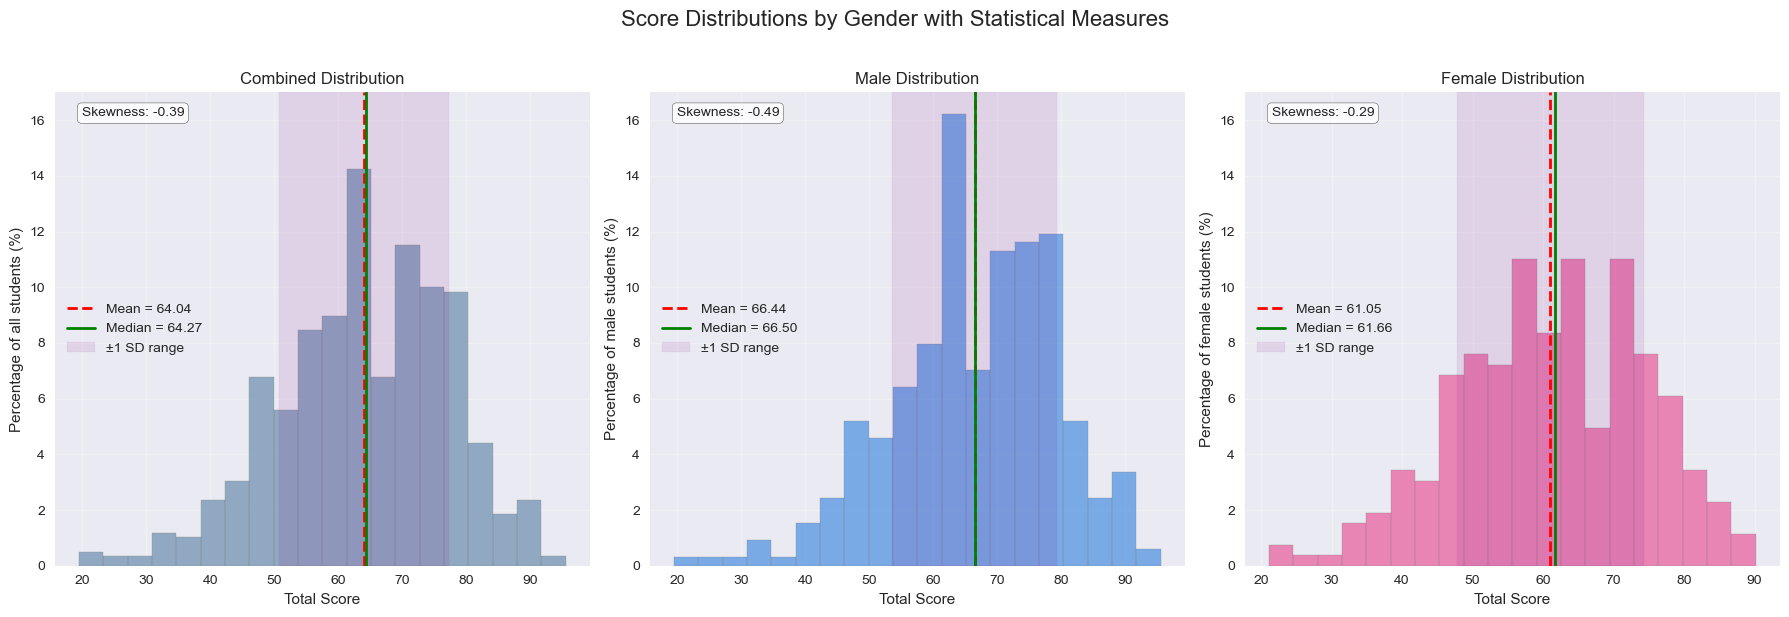

=== DISTRIBUTION SHAPE INTERPRETATION ===
Combined: approximately symmetric (skewness = -0.392)
Male: approximately symmetric (skewness = -0.487)
Female: approximately symmetric (skewness = -0.294)


In [15]:
def plot_enhanced_distributions(df, axes, title, ylabel, color='lightblue'):
    """Create enhanced distribution plots with statistical annotations"""
    mean_val = df['total_score'].mean()
    median_val = df['total_score'].median()
    std_val = df['total_score'].std()
    skew_val = df['total_score'].skew()
    
    total_students = len(df)
    
    # Create histogram with percentage weights
    axes.hist(df['total_score'], bins=20, color=color, edgecolor='gray', alpha=0.7, 
             weights=np.ones(len(df))/total_students*100)
    
    # Add statistical lines
    axes.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    axes.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    axes.axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')
    
    # Add skewness annotation
    axes.text(0.05, 0.95, f'Skewness: {skew_val:.2f}', transform=axes.transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True, alpha=0.3)
    axes.set_ylim(0, 17)
    axes.legend()

# Create enhanced distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_enhanced_distributions(df_combined, axes[0], "Combined Distribution", 
                          "Percentage of all students (%)", COLOR_COMBINED)
plot_enhanced_distributions(df_male, axes[1], "Male Distribution", 
                          "Percentage of male students (%)", COLOR_MALE)
plot_enhanced_distributions(df_female, axes[2], "Female Distribution", 
                          "Percentage of female students (%)", COLOR_FEMALE)

plt.suptitle("Score Distributions by Gender with Statistical Measures", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of skewness
print("=== DISTRIBUTION SHAPE INTERPRETATION ===")
for name, data in [("Combined", df_combined), ("Male", df_male), ("Female", df_female)]:
    skew = data['total_score'].skew()
    if abs(skew) < 0.5:
        shape = "approximately symmetric"
    elif skew > 0.5:
        shape = "right-skewed (positive skew)"
    else:
        shape = "left-skewed (negative skew)"
    print(f"{name}: {shape} (skewness = {skew:.3f})")

## 5. Statistical Hypothesis Testing

In [9]:
# Comprehensive statistical testing
def perform_statistical_tests(male_scores, female_scores):
    """Perform multiple statistical tests and calculate effect sizes"""
    
    print("=== STATISTICAL HYPOTHESIS TESTING ===")
    print("H0: No difference in mean scores between male and female students")
    print("H1: There is a difference in mean scores between groups")
    print()
    
    # Independent t-test (assuming unequal variances)
    t_stat, t_pval = ttest_ind(male_scores, female_scores, equal_var=False)
    
    # Mann-Whitney U test (non-parametric alternative)
    from scipy.stats import mannwhitneyu
    u_stat, u_pval = mannwhitneyu(male_scores, female_scores, alternative='two-sided')
    
    # Point-biserial correlation
    combined_scores = np.concatenate([male_scores, female_scores])
    gender_binary = np.concatenate([np.ones(len(male_scores)), np.zeros(len(female_scores))])
    pb_corr, pb_pval = pointbiserialr(gender_binary, combined_scores)
    
    # Cohen's d (effect size)
    pooled_std = np.sqrt(((len(male_scores)-1)*np.var(male_scores, ddof=1) + 
                          (len(female_scores)-1)*np.var(female_scores, ddof=1)) / 
                         (len(male_scores) + len(female_scores) - 2))
    cohens_d = (np.mean(male_scores) - np.mean(female_scores)) / pooled_std
    
    # Results
    print("PARAMETRIC TESTS:")
    print(f"  Welch's t-test: t = {t_stat:.4f}, p = {t_pval:.4f}")
    print(f"  Significant at α=0.05: {t_pval < 0.05}")
    
    print("\nNON-PARAMETRIC TESTS:")
    print(f"  Mann-Whitney U: U = {u_stat:.1f}, p = {u_pval:.4f}")
    print(f"  Significant at α=0.05: {u_pval < 0.05}")
    
    print("\nCORRELATION ANALYSIS:")
    print(f"  Point-biserial correlation: r = {pb_corr:.4f}, p = {pb_pval:.4f}")
    print(f"  Variance explained (R²): {pb_corr**2:.4f} ({pb_corr**2*100:.1f}%)")
    
    print("\nEFFECT SIZE:")
    print(f"  Cohen's d = {cohens_d:.4f}")
    
    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    print(f"  Effect size magnitude: {effect_size}")
    
    return {
        't_stat': t_stat, 't_pval': t_pval,
        'u_stat': u_stat, 'u_pval': u_pval,
        'pb_corr': pb_corr, 'pb_pval': pb_pval,
        'cohens_d': cohens_d, 'effect_size': effect_size
    }

# Run statistical tests
test_results = perform_statistical_tests(df_male['total_score'], df_female['total_score'])

=== STATISTICAL HYPOTHESIS TESTING ===
H0: No difference in mean scores between male and female students
H1: There is a difference in mean scores between groups

PARAMETRIC TESTS:
  Welch's t-test: t = 4.9649, p = 0.0000
  Significant at α=0.05: True

NON-PARAMETRIC TESTS:
  Mann-Whitney U: U = 53101.0, p = 0.0000
  Significant at α=0.05: True

CORRELATION ANALYSIS:
  Point-biserial correlation: r = 0.2013, p = 0.0000
  Variance explained (R²): 0.0405 (4.1%)

EFFECT SIZE:
  Cohen's d = 0.4127
  Effect size magnitude: small


## 6. Outlier Analysis

=== OUTLIER ANALYSIS ===
Combined: 5 outliers (0.8%)
  Range: 19.50 - 27.00
Male: 5 outliers (1.5%)
  Range: 19.50 - 32.00
Female: 1 outliers (0.4%)
  Range: 21.15 - 21.15


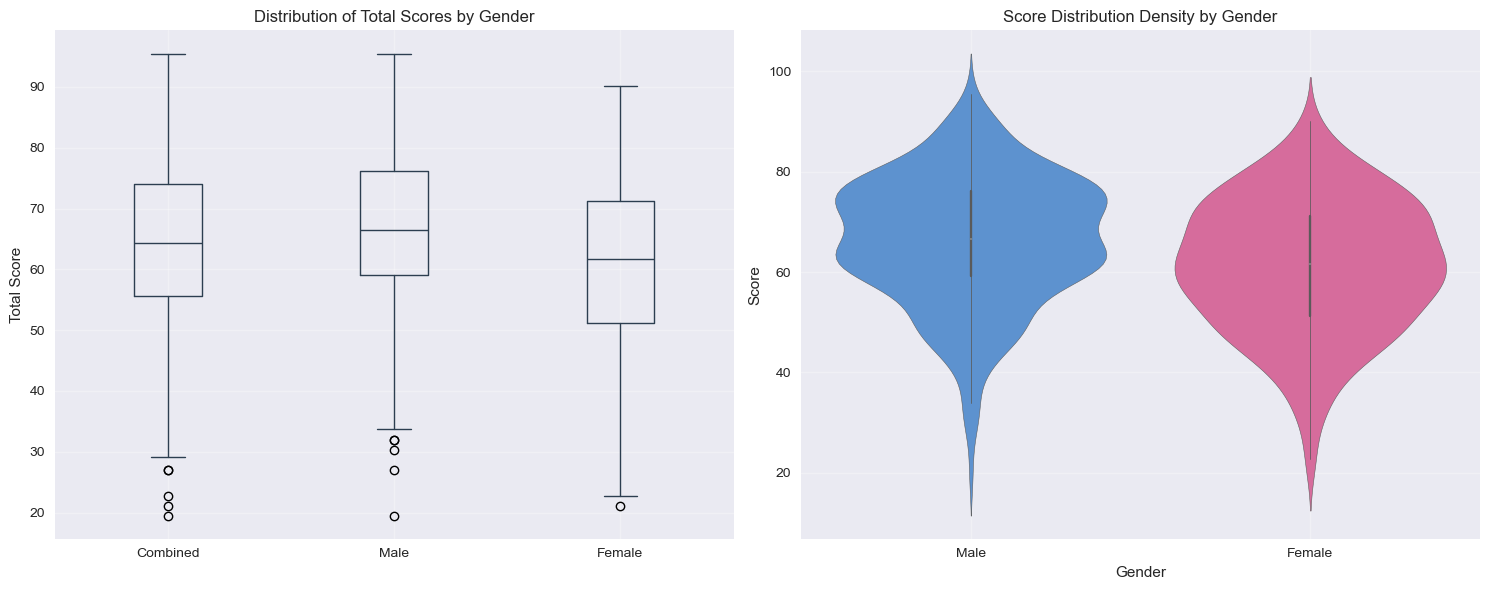

In [10]:
# Enhanced boxplot analysis with outlier identification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Score outliers
df_outliers = pd.DataFrame({
    'Combined': df_combined['total_score'],
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})

boxplot1 = df_outliers.boxplot(ax=ax1, return_type='dict', color=COLOR_BOXPLOT)
ax1.set_title('Distribution of Total Scores by Gender')
ax1.set_ylabel('Total Score')
ax1.grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

print("=== OUTLIER ANALYSIS ===")
combined_outliers = identify_outliers(df_combined['total_score'], "Combined")
male_outliers = identify_outliers(df_male['total_score'], "Male")
female_outliers = identify_outliers(df_female['total_score'], "Female")

# Violin plot for better distribution visualization
df_melted = pd.melt(df_outliers.reset_index(), id_vars='index', 
                    value_vars=['Male', 'Female'], 
                    var_name='Gender', value_name='Score')
df_melted = df_melted.dropna()

sns.violinplot(data=df_melted, x='Gender', y='Score', hue='Gender', ax=ax2, 
               palette={'Male': COLOR_MALE, 'Female': COLOR_FEMALE}, legend=False)
ax2.set_title('Score Distribution Density by Gender')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Time Analysis

In [11]:
# Time analysis descriptive statistics
time_stats = pd.DataFrame([
    calculate_descriptive_stats(df_time['time_taken'], 'Combined'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'M']['time_taken'], 'Male'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'F']['time_taken'], 'Female')
]).T

print("=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===")
print(time_stats)

=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===
          Combined     Male   Female
Count      590.000  327.000  263.000
Mean       205.840  194.970  219.360
Median     226.460  208.000  235.380
Mode       240.050  240.050  239.530
Std Dev     43.950   46.390   36.520
Min         44.580   44.580   93.200
Max        300.670  271.180  300.670
Q1         180.420  164.180  207.980
Q3         239.020  236.340  239.860
IQR         58.590   72.160   31.880
Skewness    -1.064   -0.800   -1.474
Kurtosis     0.348   -0.328    2.027


=== TIME OUTLIER ANALYSIS ===
Combined Time: 6 outliers (1.0%)
  Range: 44.58 - 91.32
Male Time: 1 outliers (0.3%)
  Range: 44.58 - 44.58
Female Time: 27 outliers (10.3%)
  Range: 93.20 - 300.67


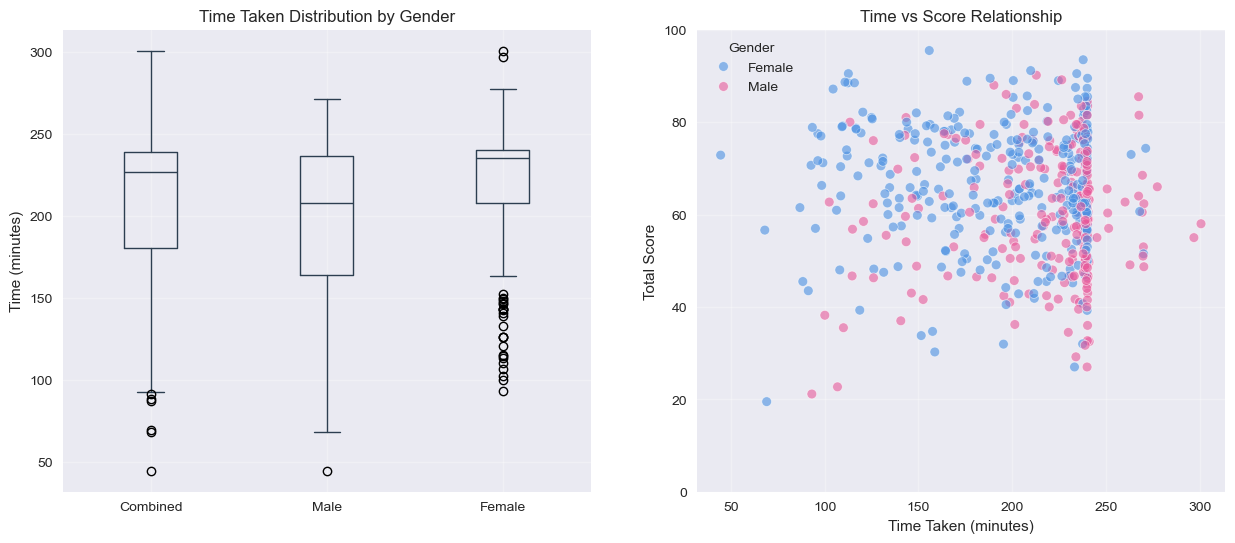

<Figure size 800x550 with 0 Axes>

In [12]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_clean = df_time.dropna(subset=['time_taken'])
df_time_outliers = pd.DataFrame({
    'Combined': df_time_clean['time_taken'],
    'Male': df_time_clean[df_time_clean['gender'] == 'M']['time_taken'],
    'Female': df_time_clean[df_time_clean['gender'] == 'F']['time_taken']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time_clean['time_taken'], "Combined Time")
time_male_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'M']['time_taken'], "Male Time")
time_female_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'F']['time_taken'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time_clean, x='time_taken', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
# Update legend labels for clarity
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Female', 'Male'], title='Gender')


plt.show()
plt.tight_layout()

In [13]:
print("=== TIME-SCORE CORRELATION ANALYSIS ===")

# Pearson correlation (for normally distributed data)
pearson_corr, pearson_p = pearsonr(df_time['time_taken'], df_time['total_score'])
print(f"Pearson correlation: r = {pearson_corr:.4f}, p = {pearson_p:.4f}")

# Spearman correlation (non-parametric alternative)
spearman_corr, spearman_p = spearmanr(df_time['time_taken'], df_time['total_score'])
print(f"Spearman correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")

# Interpretation
if abs(pearson_corr) < 0.1:
    strength = "negligible"
elif abs(pearson_corr) < 0.3:
    strength = "weak"
elif abs(pearson_corr) < 0.5:
    strength = "moderate"
elif abs(pearson_corr) < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if pearson_corr > 0 else "negative"

print(f"\nInterpretation: {strength} {direction} correlation")
print(f"Shared variance: {pearson_corr**2:.1%}")

# Gender-specific correlations
male_time_data = df_time[df_time['gender'] == 'M']
female_time_data = df_time[df_time['gender'] == 'F']

male_corr, male_p = pearsonr(male_time_data['time_taken'], male_time_data['total_score'])
female_corr, female_p = pearsonr(female_time_data['time_taken'], female_time_data['total_score'])

print(f"\n=== GENDER-SPECIFIC CORRELATIONS ===")
print(f"Male: r = {male_corr:.4f}, p = {male_p:.4f}")
print(f"Female: r = {female_corr:.4f}, p = {female_p:.4f}")

=== TIME-SCORE CORRELATION ANALYSIS ===
Pearson correlation: r = -0.0360, p = 0.3825
Spearman correlation: ρ = -0.0844, p = 0.0403

Interpretation: negligible negative correlation
Shared variance: 0.1%

=== GENDER-SPECIFIC CORRELATIONS ===
Male: r = -0.0275, p = 0.6201
Female: r = 0.0951, p = 0.1240


## 9. Summary and Conclusions

Let's synthesize our findings and provide actionable insights.

In [14]:
# Comprehensive summary analysis
def create_summary_report():
    """Generate a comprehensive summary of all analyses"""
    
    print("=" * 70)
    print("                    EXECUTIVE SUMMARY")
    print("           Gender Analysis of IN1020 Exam Performance 2024")
    print("=" * 70)
    
    # Sample characteristics
    total_students = len(df_combined)
    male_count = len(df_male)
    female_count = len(df_female)
    
    print(f"\n📊 SAMPLE CHARACTERISTICS:")
    print(f"   • Total Students: {total_students}")
    print(f"   • Male Students: {male_count} ({male_count/total_students*100:.1f}%)")
    print(f"   • Female Students: {female_count} ({female_count/total_students*100:.1f}%)")
    print(f"   • Gender Balance: {'Balanced' if abs(male_count-female_count)/total_students < 0.2 else 'Imbalanced'}")
    
    # Performance summary
    male_mean = df_male['total_score'].mean()
    female_mean = df_female['total_score'].mean()
    mean_diff = male_mean - female_mean
    
    print(f"\n📈 PERFORMANCE METRICS:")
    print(f"   • Overall Mean Score: {df_combined['total_score'].mean():.2f}")
    print(f"   • Male Mean Score: {male_mean:.2f}")
    print(f"   • Female Mean Score: {female_mean:.2f}")
    print(f"   • Mean Difference: {mean_diff:.2f} points ({abs(mean_diff)/female_mean*100:.1f}%)")
    print(f"   • Direction: {'Males score higher' if mean_diff > 0 else 'Females score higher' if mean_diff < 0 else 'No difference'}")
    
    # Statistical significance
    if 'test_results' in globals():
        t_pval = test_results['t_pval']
        cohens_d = test_results['cohens_d']
        effect_size = test_results['effect_size']
        
        print(f"\n📊 STATISTICAL FINDINGS:")
        print(f"   • Statistical Significance: {'Yes' if t_pval < 0.05 else 'No'} (p = {t_pval:.4f})")
        print(f"   • Effect Size (Cohen's d): {cohens_d:.3f} ({effect_size})")
        print(f"   • Practical Significance: {'Yes' if abs(cohens_d) >= 0.2 else 'No'}")

    
    # Key recommendations
    print(f"\n💡 KEY INSIGHTS & RECOMMENDATIONS:")
    
    if abs(mean_diff) < 2:
        print("   • Gender differences in performance are minimal")
        print("   • Focus on individual support rather than gender-specific interventions")
    elif test_results['effect_size'] in ['small', 'negligible']:
        print("   • Observed differences are statistically small")
        print("   • Monitor trends but current differences may not warrant intervention")
    else:
        print("   • Notable gender differences warrant attention")
        print("   • Consider targeted support for underperforming group")
    
    print("   • Continue monitoring for trends over time")
    print("   • Investigate factors beyond gender that influence performance")
    print("   • Ensure exam design is gender-neutral")
    
    print("\n" + "=" * 70)

# Generate the report
create_summary_report()

                    EXECUTIVE SUMMARY
           Gender Analysis of IN1020 Exam Performance 2024

📊 SAMPLE CHARACTERISTICS:
   • Total Students: 590
   • Male Students: 327 (55.4%)
   • Female Students: 263 (44.6%)
   • Gender Balance: Balanced

📈 PERFORMANCE METRICS:
   • Overall Mean Score: 64.04
   • Male Mean Score: 66.44
   • Female Mean Score: 61.05
   • Mean Difference: 5.39 points (8.8%)
   • Direction: Males score higher

📊 STATISTICAL FINDINGS:
   • Statistical Significance: Yes (p = 0.0000)
   • Effect Size (Cohen's d): 0.413 (small)
   • Practical Significance: Yes

💡 KEY INSIGHTS & RECOMMENDATIONS:
   • Observed differences are statistically small
   • Monitor trends but current differences may not warrant intervention
   • Continue monitoring for trends over time
   • Investigate factors beyond gender that influence performance
   • Ensure exam design is gender-neutral

